In [101]:
import xarray as xr
import arviz as az
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import colormaps as cm
from fit_trajectories import gof_trajectories

In [34]:
res = az.from_netcdf("C:/Users/mgrho/Expression_baseline_models/results/numpyro_posterior_test")
res

Inference data with groups:
	> posterior
	> posterior_predictive
	> log_likelihood
	> sample_stats
	> observed_data
	> posterior_model_fits
	> posterior_residuals

In [22]:
def calc_nrmse(obs, pred):
    '''Normalized Root Mean Square Error'''
    rmse = np.sqrt(np.mean((obs - pred)**2))

    # by range
    nrmse_range = rmse / (obs.max() - obs.min())
    # by mean
    nrmse_mean = rmse / obs.mean()
    # by std
    nrmse_std = rmse / obs.std()

    return [nrmse_range, nrmse_mean, nrmse_std]

In [23]:
def rmse(x_0: xr.DataArray, x: xr.DataArray):
    n = x.count()
    dims_sum = [d for d in x_0.dims if d not in ["chain", "draw"]]
    return np.sqrt((1 / n * np.power(x - x_0, 2).sum(dims_sum)))


def nrmse(x_0: xr.DataArray, x: xr.DataArray, mode= "range"):
    dims_sum = [d for d in x_0.dims if d not in ["chain", "draw"]]

    if mode == "range":
        return rmse(x_0, x) / (x.max(dims_sum) - x.min(dims_sum))
    elif mode == "mean":
        return rmse(x_0, x) / x.mean(dims_sum)
    elif mode == "mean":
        return rmse(x_0, x) / x.mean(dims_sum)
    else:
        raise NotImplementedError(
            f"Mode {mode} not implemented. Use one of the following modes"
        )


### 120 hpf

In [55]:
ds = xr.load_dataset("../data/genes_tpms_white_pauli_JN_BK_mean.nc")
ds["tpm"] = np.log2(ds.tpm + 1)

ds_clean = ds.dropna(dim="time", how="all", subset=["tpm"])
mask = (ds_clean.tpm.max(dim="time", skipna=True) >= 1).any(dim="source")
ds_filtered = ds.sel(ensembl_gene_id=mask)

traj120 = xr.load_dataarray("results/gene_trajectories_120.nc")
gof120 = pd.read_csv("results/gof_trajectories_120.csv")
gof120.groupby("source").sum("accepted") / gof120.groupby("source").count().drop(columns="ensembl_gene_id")

,nrmse,accepted
source,,
BK,0.157002,0.351889
JN,0.208468,0.372707
Pauli,0.311825,0.108547
White,0.172389,0.310983


Mean NRMSE:  source
BK       0.157002
JN       0.208468
Pauli    0.311825
White    0.172389
Name: nrmse, dtype: float64 

Accepted %:  source
BK       0.351889
JN       0.372707
Pauli    0.108547
White    0.310983
dtype: float64


<Axes: title={'center': 'Accepted NRMSE by Source (120h)'}, ylabel='Source'>

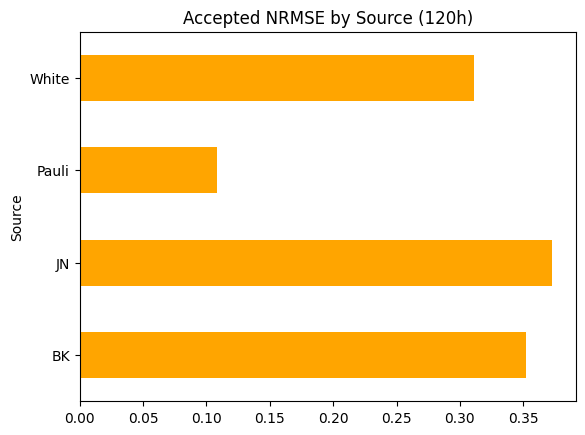

In [ ]:
print("Mean NRMSE: ", gof120.groupby("source").nrmse.mean(), "\n")
gof120.groupby("source").nrmse.mean().plot.barh(color="orange", ylabel="Source", y="Mean NRMSE", title="Mean NRMSE by Source (120h)")
plt.close()
(gof120.groupby("source").accepted.sum() / gof120.groupby("source").count()["ensembl_gene_id"]).plot.barh(color="orange", ylabel="Source", y="% accepted", title="Accepted NRMSE by Source (120h)")

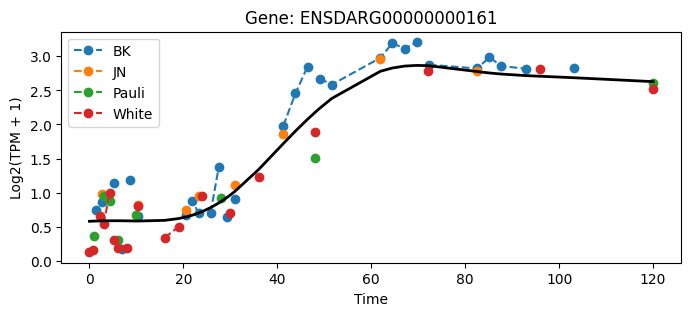

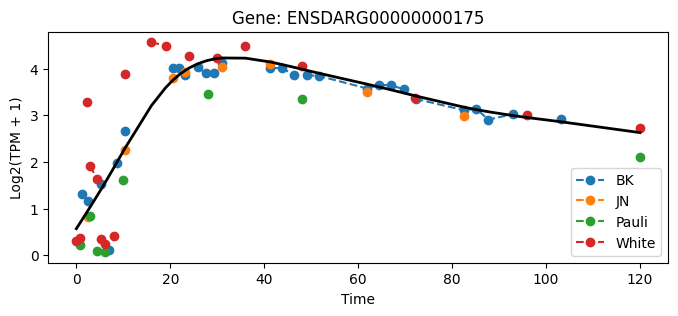

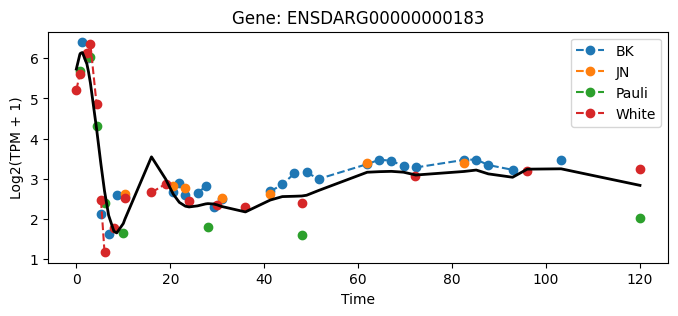

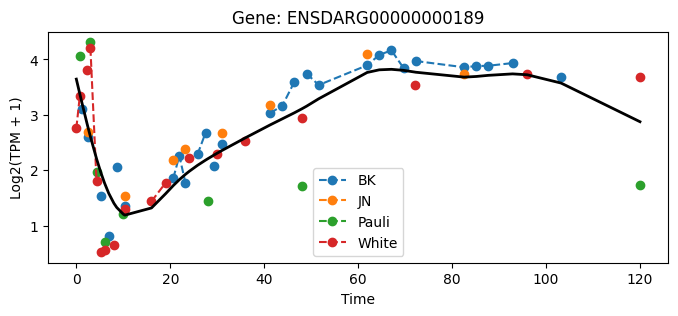

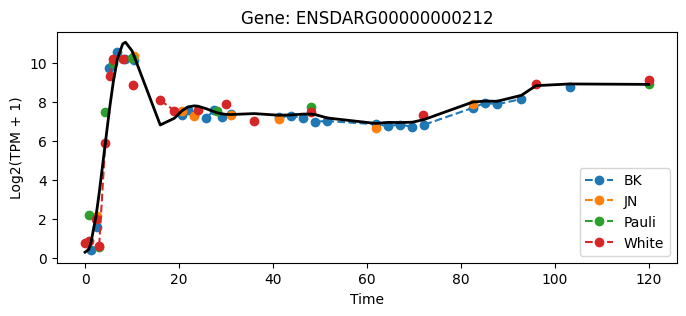

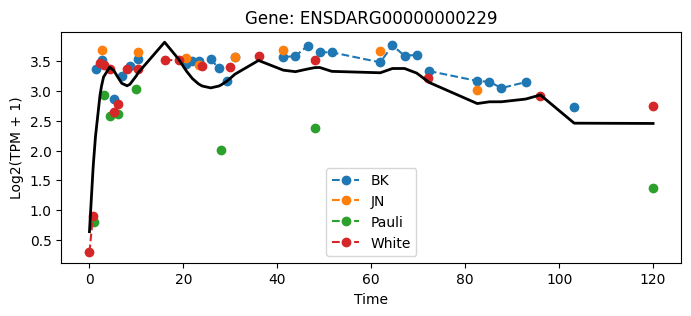

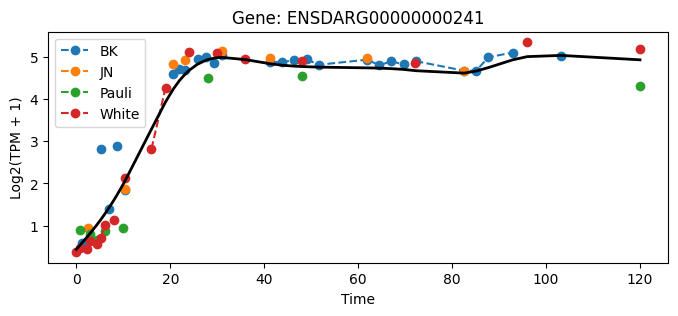

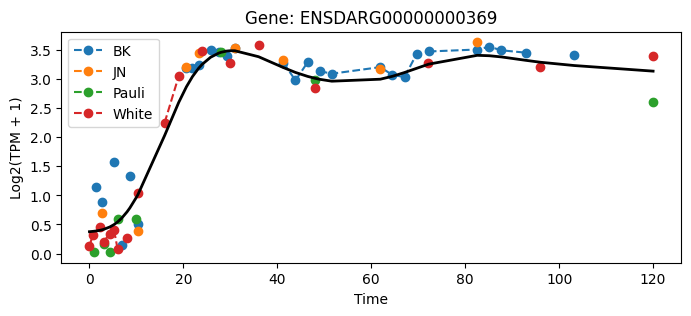

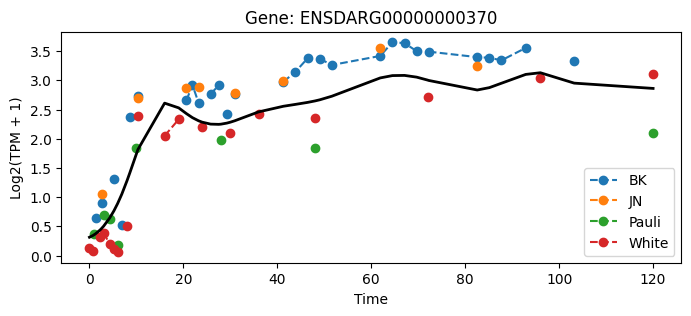

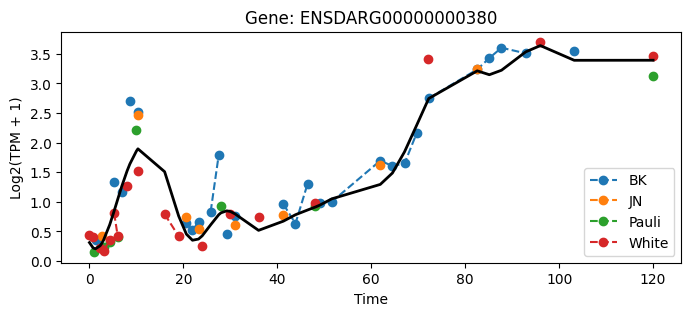

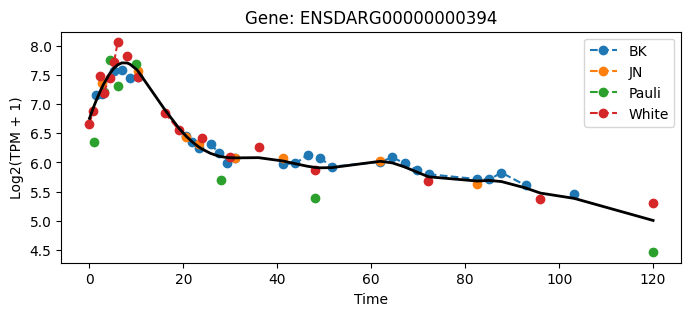

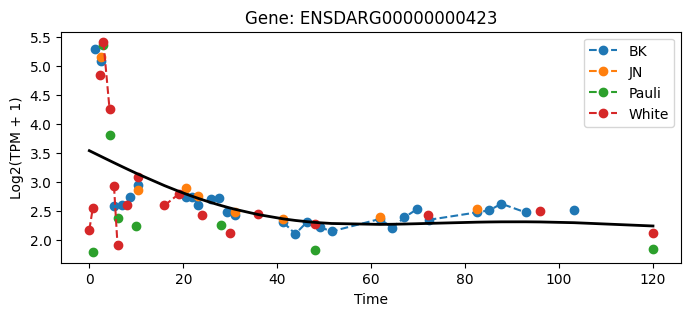

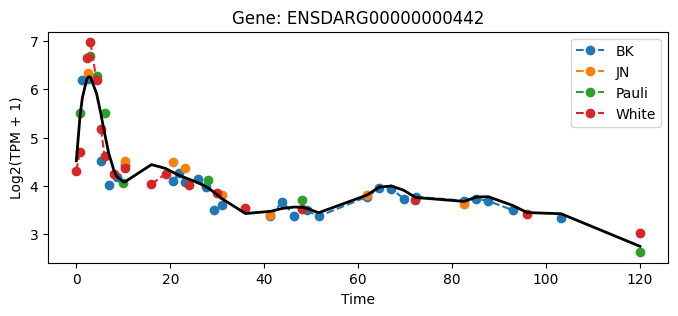

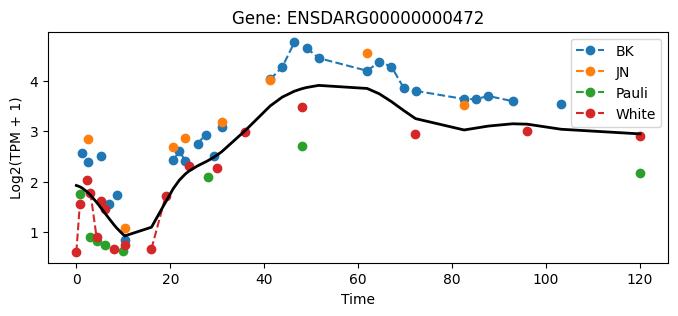

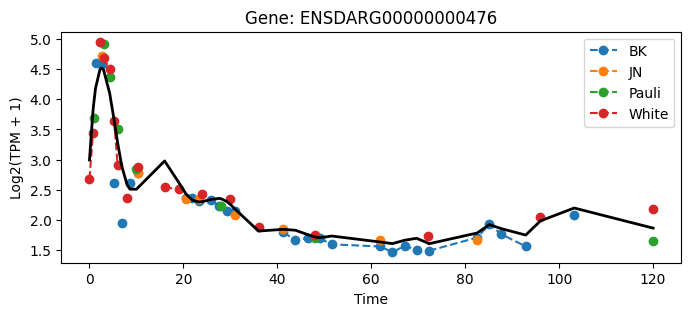

In [17]:
sc = ds.source.values

for g in traj120.ensembl_gene_id.values[10:25]:
    y_true = ds_filtered.sel(ensembl_gene_id=g, drop=True).tpm
    y_pred = traj120.sel(ensembl_gene_id=g, drop=True)
    plt.figure(figsize=(8, 3))
    plt.plot(ds_filtered.time, y_true, marker="o", ls="--", label=sc)
    plt.plot(ds_filtered.time, y_pred, "k", lw=2)
    plt.title(f"Gene: {g}")
    plt.xlabel("Time")
    plt.ylabel("Log2(TPM + 1)")
    plt.legend()
    plt.show()

### 24 hpf

In [52]:
ds24 = xr.load_dataset("../data/genes_tpms_white_pauli_JN_BK_mean.nc").sel(time=slice(0, 24))
ds24["tpm"] = np.log2(ds24.tpm + 1)

ds_clean24 = ds24.dropna(dim="time", how="all", subset=["tpm"])
mask = (ds_clean24.tpm.max(dim="time", skipna=True) >= 1).any(dim="source")
ds_filtered24 = ds_clean24.sel(ensembl_gene_id=mask)

traj24 = xr.load_dataarray("results/gene_trajectories_24.nc")
gof24 = pd.read_csv("results/gof_trajectories_24.csv")
gof24.groupby("source").sum("accepted") / gof24.groupby("source").count().drop(columns="ensembl_gene_id")

,nrmse,accepted
source,,
BK,0.260398,0.145239
JN,0.333862,0.239582
Pauli,0.527503,0.044700
White,0.208357,0.247937


Mean NRMSE:  source
BK       0.260398
JN       0.333862
Pauli    0.527503
White    0.208357
Name: nrmse, dtype: float64 



<Axes: title={'center': 'Accepted NRMSE by Source (24 hpf)'}, ylabel='Source'>

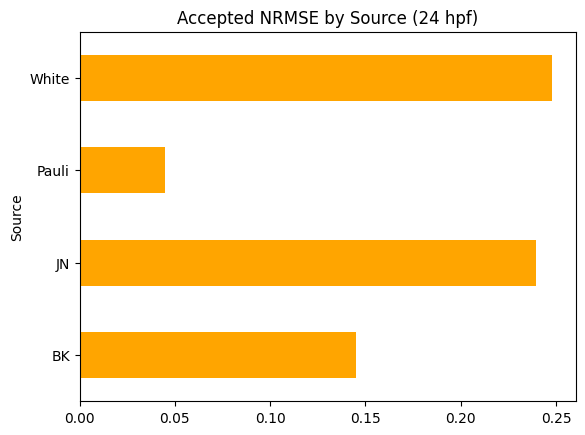

In [53]:
print("Mean NRMSE: ", gof24.groupby("source").nrmse.mean(), "\n")
gof24.groupby("source").nrmse.mean().plot.barh(color="orange", ylabel="Source", y="Mean NRMSE", title="Mean NRMSE by Source (24)")
plt.close()

(gof24.groupby("source").accepted.sum() / gof24.groupby("source").count()["ensembl_gene_id"]).plot.barh(color="orange", ylabel="Source", y="% accepted", title="Accepted NRMSE by Source (24 hpf)")

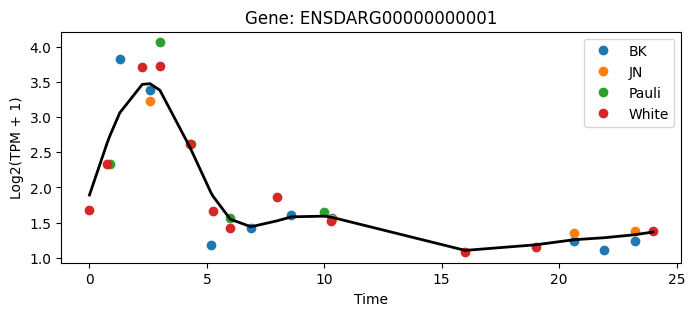

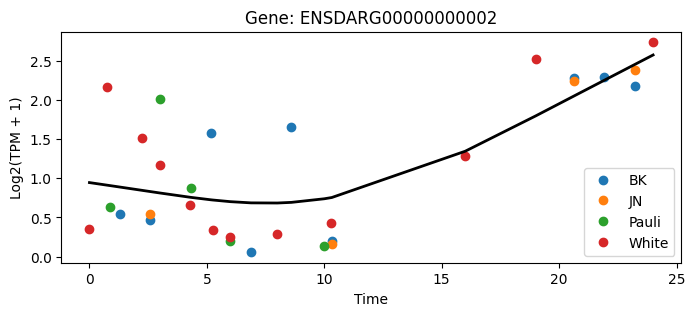

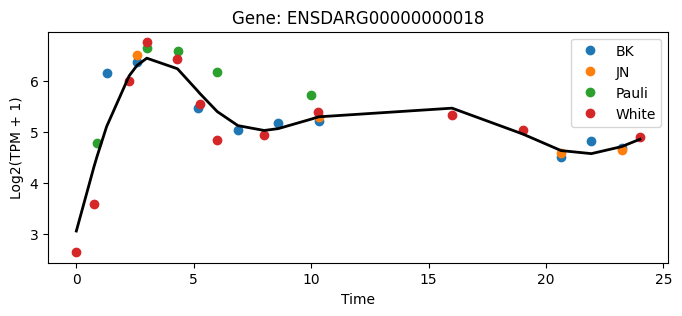

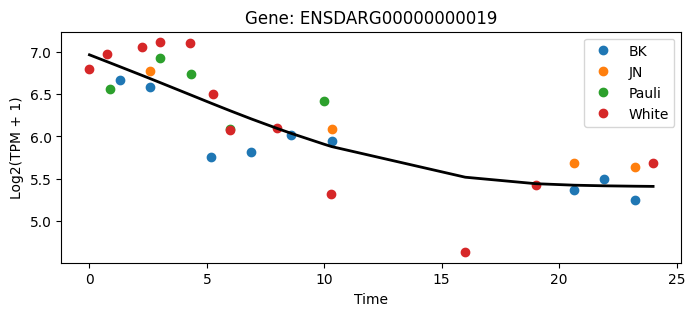

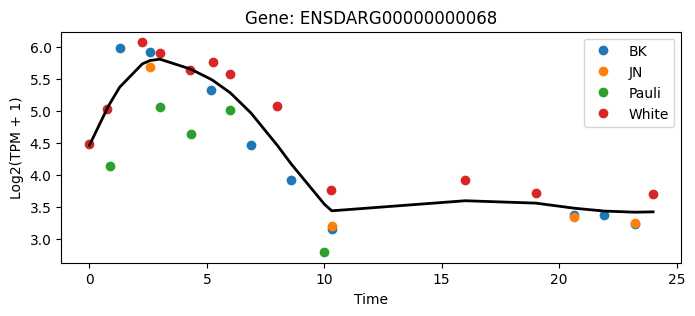

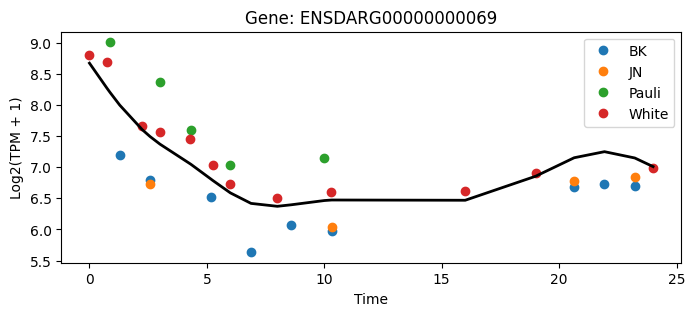

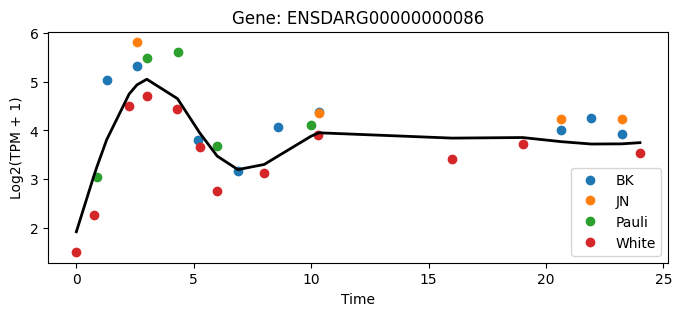

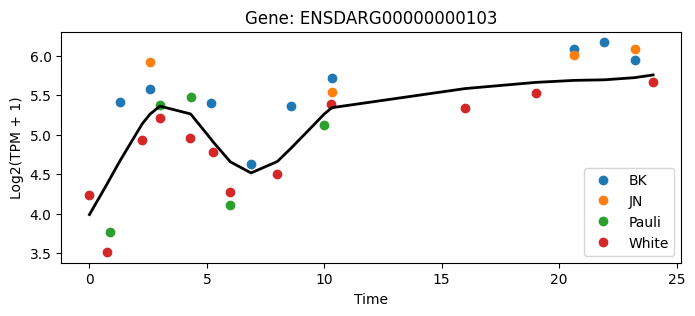

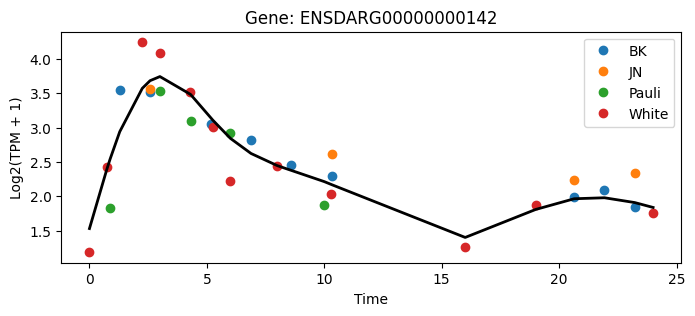

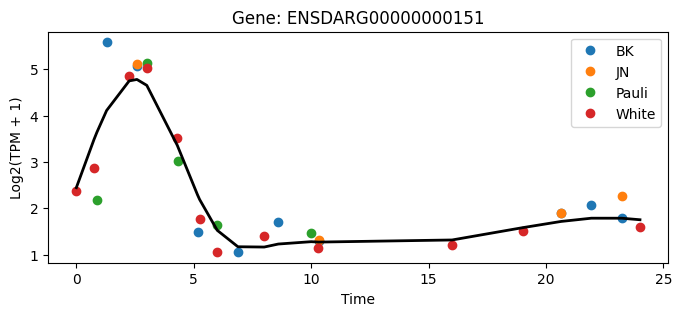

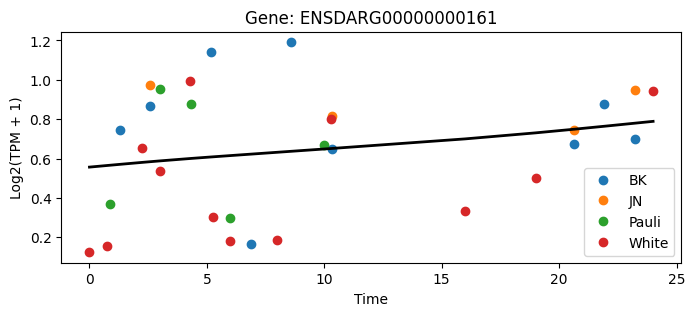

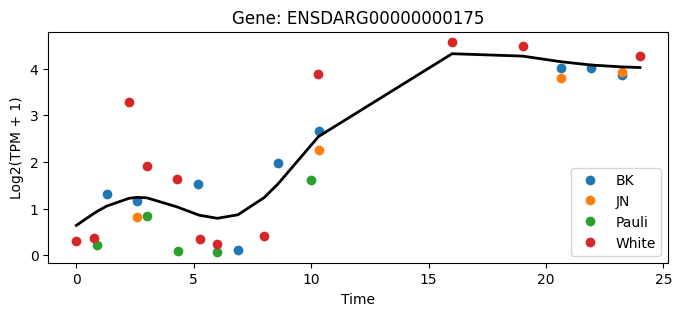

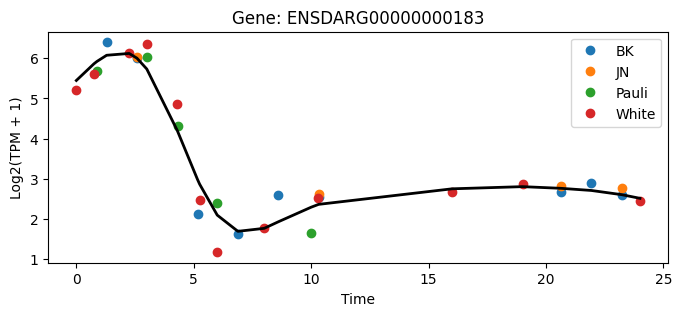

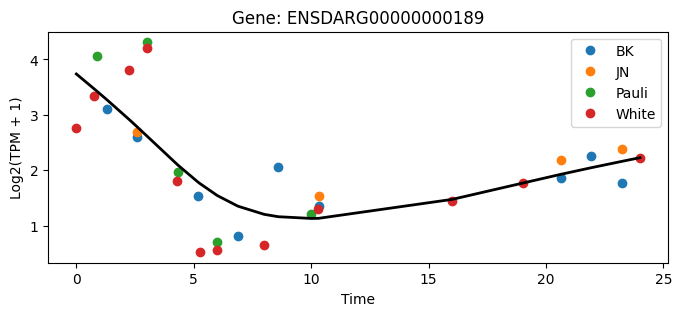

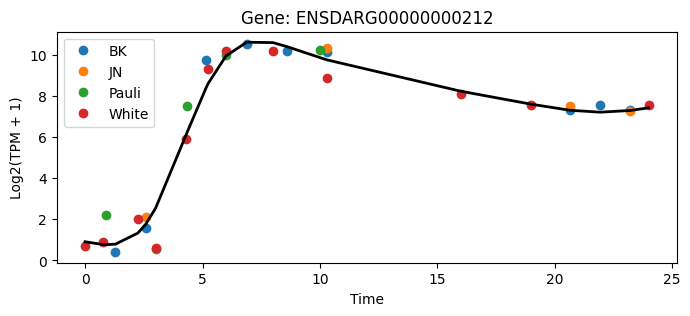

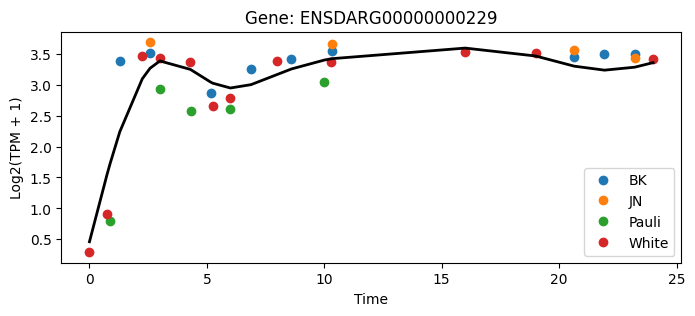

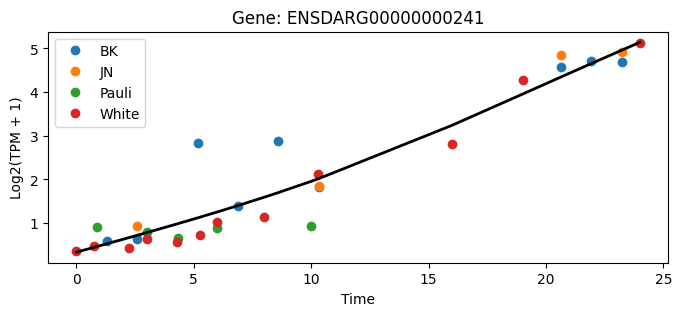

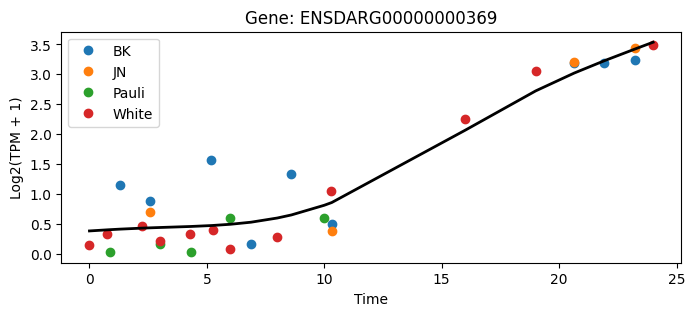

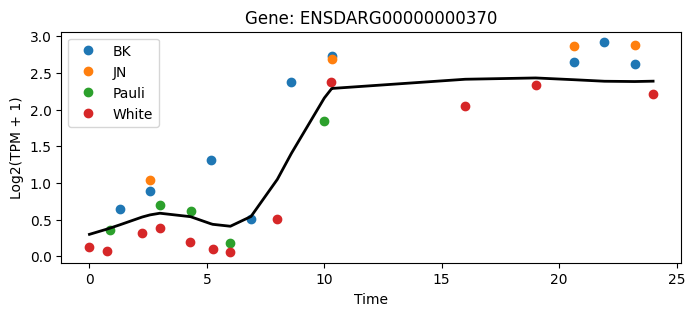

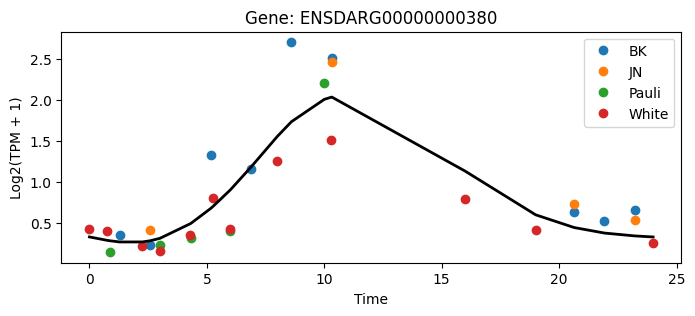

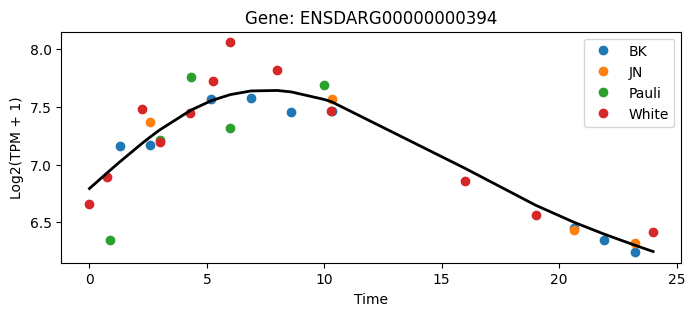

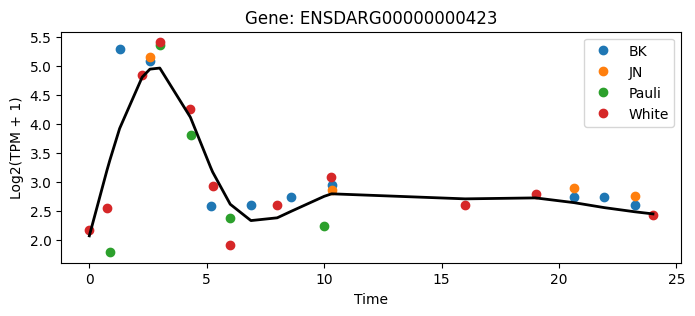

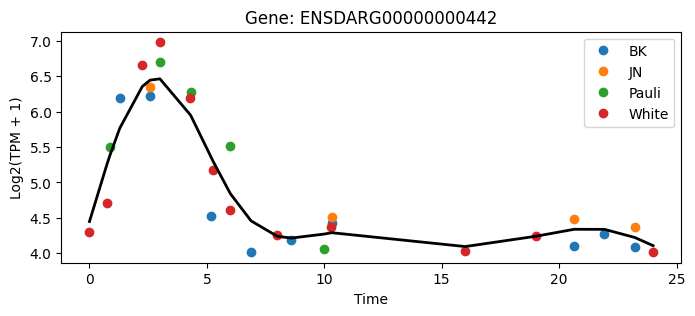

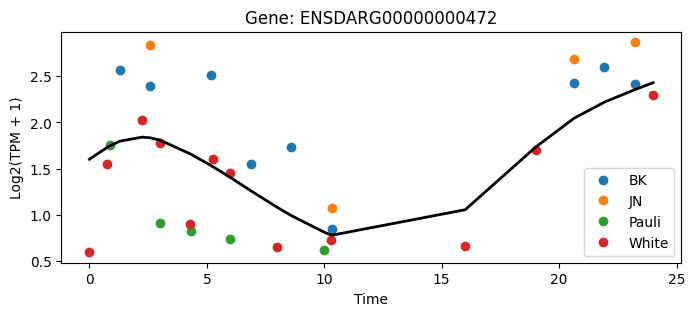

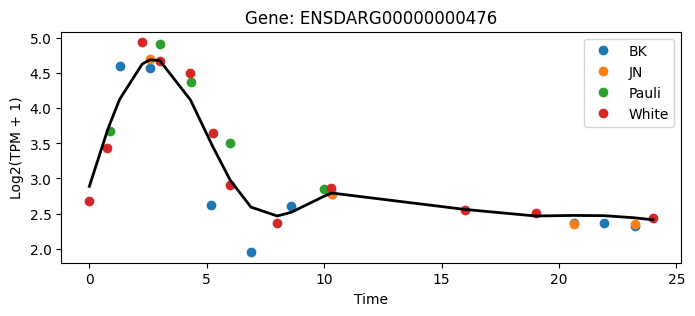

In [30]:
sc = ds24.source.values

for g in traj24.ensembl_gene_id.values[0:25]:
    y_true = ds_filtered24.sel(ensembl_gene_id=g, drop=True).tpm
    y_pred = traj24.sel(ensembl_gene_id=g, drop=True)
    plt.figure(figsize=(8,3))
    plt.plot(ds_filtered24.time, y_true,  marker="o", ls="", label=sc)
    plt.plot(ds_filtered24.time, y_pred, "k", lw=2)
    plt.title(f"Gene: {g}")
    plt.xlabel("Time")
    plt.ylabel("Log2(TPM + 1)")
    plt.legend()
    plt.show()

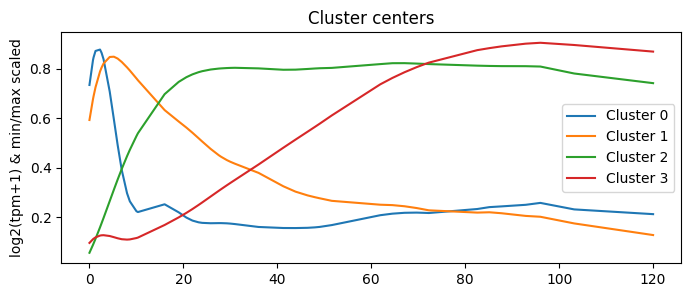

In [31]:
fuzzy_cntr = xr.load_dataarray("results/all_superclusters_centers.nc")
#peak = fuzzy_cntr.values.argmax(axis=1)
#fuzzy_cntr = fuzzy_cntr.isel(cluster=np.argsort(peak))

plt.figure(figsize=(8,3))
for c in range(fuzzy_cntr.shape[0]):
    plt.plot(fuzzy_cntr.time, fuzzy_cntr[c, :], label=f"Cluster {c}")
plt.title("Cluster centers")
plt.ylabel("log2(tpm+1) & min/max scaled")
plt.legend()
plt.show()

### heatmap

In [27]:
import seaborn as sns
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

def plot_heatmap_supercluster(annotation_path, cluster_col="supercluster", data_name="all",
                  algo="hierarchical", source=None, norm="minmax", supercluster=None):

    # load annotated dataset (supercluster, subcluster, tpm)
    ann = xr.load_dataset(annotation_path)

    if supercluster != None:
        ann = ann.where(ann.supercluster == supercluster, drop=True).sel(time=slice(0, 24))

    # select expression data: average over source, or pick one if specified
    if "source" in ann.tpm.dims:
        if source is not None:
            ann = ann.sel(source=source, drop=True)
            ann = ann.dropna(dim="time", how="all", subset=["tpm"])
            tpm = ann.tpm
        else:
            tpm = ann.tpm.mean(dim="source", skipna=True)
    else:
        tpm = ann.tpm

    tpm = tpm.transpose("ensembl_gene_id", "time")

    # drop genes with no valid time points
    valid = np.isfinite(tpm).any(dim="time")
    tpm = tpm.sel(ensembl_gene_id=valid)
    ann = ann.sel(ensembl_gene_id=tpm.ensembl_gene_id)

    # normalise per gene, same scheme as in fuzzy_cmeans
    tpm = np.log2(tpm+1)

    if norm == "minmax":
        X_z = (tpm - tpm.min("time")) / (tpm.max("time") - tpm.min("time"))
    elif norm == "meanmax":
        dev = tpm - tpm.mean("time")
        denom = abs(dev).max("time")
        denom = denom.where(denom > 0)
        X_z = dev / denom
    else:
        print("[ERROR] Provide valid normalisation method (minax, meanmax)")
        return

    still_valid = np.isfinite(X_z).any(dim="time")
    print(f"[debug] genes surviving normalisation: {int(still_valid.sum())} / {still_valid.size}")

    X_z = X_z.sel(ensembl_gene_id=still_valid)
    ann = ann.sel(ensembl_gene_id=X_z.ensembl_gene_id)

    if X_z.sizes["ensembl_gene_id"] == 0:
        raise ValueError(
            f"No genes remain after filtering for source={source!r}. "
            "Check that this source has enough non-NaN time points per gene."
        )

    # cluster labels
    clusters = ann[cluster_col].values

    # time axis (index of max expression per gene)
    time_idx = X_z.argmax(dim="time", skipna=True).values

    # build structured sort: first cluster, then peak time
    sorted_genes = np.lexsort((time_idx, clusters))
    expr_plot = X_z.isel(ensembl_gene_id=sorted_genes)
    sorted_clusters = clusters[sorted_genes]

    # unique clusters in sorted order
    unique_clusters, start_idx = np.unique(sorted_clusters, return_index=True)
    end_idx = np.r_[start_idx[1:], len(sorted_clusters)]
    centers = (start_idx + end_idx) / 2

    cluster_cmap = ListedColormap(sns.color_palette("Set1", len(np.unique(clusters))))

    fig = plt.figure(figsize=(8, 7))
    gs = fig.add_gridspec(1, 2, width_ratios=[0.015, 1], wspace=0.01)

    # Cluster bar (left)
    ax_bar = fig.add_subplot(gs[0])
    ax_bar.imshow(sorted_clusters[:, None], aspect='auto', cmap=cluster_cmap)
    ax_bar.set_xticks([])
    ax_bar.set_yticks([])

    for c, y in zip(unique_clusters, centers):
        ax_bar.text(0.05, y, str(c),
                    ha='center', va='center',
                    fontsize=12, fontweight='bold',
                    color='black',
                    transform=ax_bar.transData)

    # Heatmap
    ax = fig.add_subplot(gs[1])
    sns.heatmap(expr_plot.values,
                cmap='Spectral_r',
                yticklabels=False, xticklabels=expr_plot.time.values,
                ax=ax, cbar_kws={'label': 'expression', 'shrink': 0.5, 'pad': 0.02})

    if supercluster != None:
        ax.set_title(f'Gene expression pattern in $D. rerio$ ({algo}, {data_name} {supercluster})', fontsize=12) 
    else:
        ax.set_title(f'Gene expression pattern in $D. rerio$ ({algo}, {data_name})', fontsize=12) 

    ax.set(xlabel='time (hpf)', ylabel='')

    ax.vlines(3.5, *ax.get_ylim(), colors='k', linewidth=1, ls='--')

    # Find cluster boundaries
    boundaries = np.where(np.diff(sorted_clusters) != 0)[0]
    for b in boundaries:
        ax.hlines(b, *ax.get_xlim(), colors='k', linewidth=1.5)

    plt.tight_layout()
    plt.savefig(f"figs/{algo}_cluster_heatmap_{data_name}_{cluster_col}_{supercluster}.png",
                dpi=300, transparent=True)
    plt.show()

[debug] genes surviving normalisation: 19456 / 19456


C:\Users\mgrho\AppData\Local\Temp\ipykernel_14780\3476123217.py:115: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


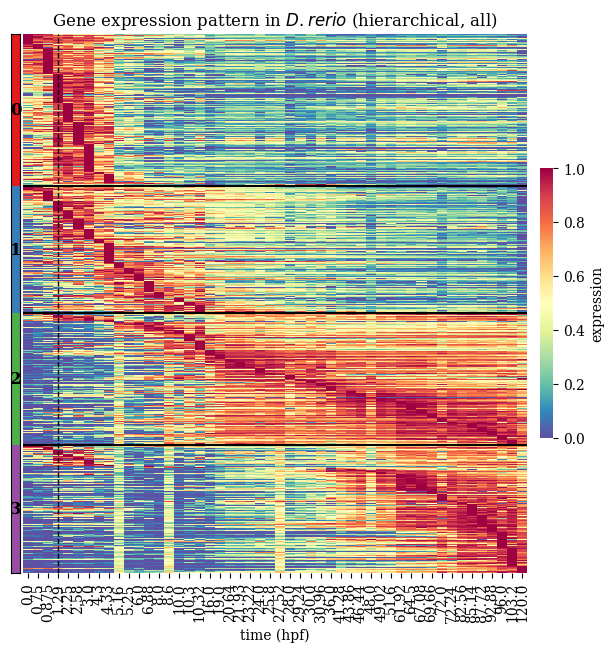

In [50]:
plot_heatmap_supercluster("results/all_gene_cluster_annotation_minmax.nc", cluster_col="supercluster",
             data_name="all", algo="hierarchical", )

[debug] genes surviving normalisation: 19264 / 19456


C:\Users\mgrho\AppData\Local\Temp\ipykernel_14780\3476123217.py:115: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


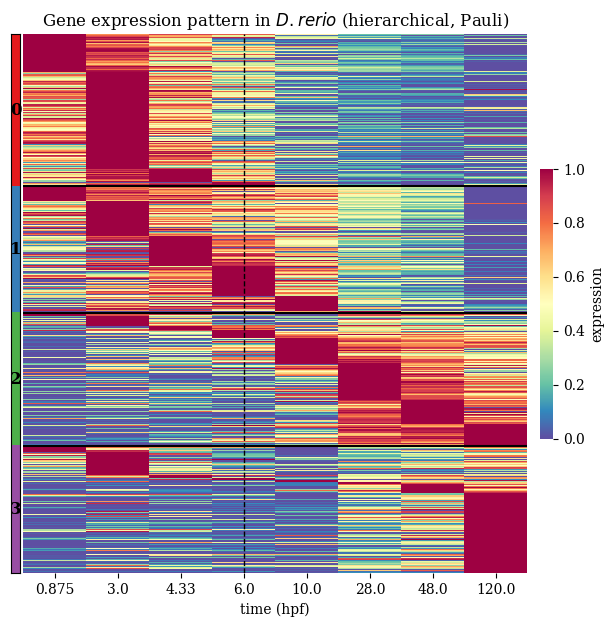

In [51]:
plot_heatmap_supercluster("results/all_gene_cluster_annotation_minmax.nc", cluster_col="supercluster",
             data_name="Pauli", algo="hierarchical", source="Pauli et al.")

[debug] genes surviving normalisation: 19360 / 19456


C:\Users\mgrho\AppData\Local\Temp\ipykernel_14780\3476123217.py:115: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


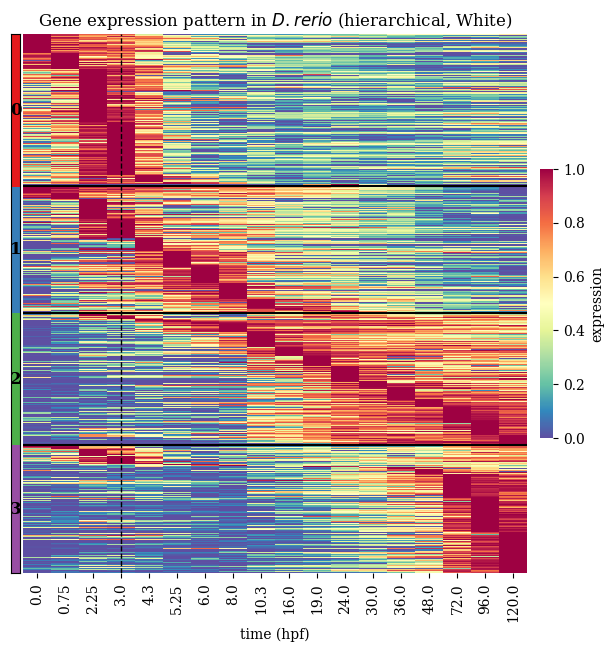

In [52]:
plot_heatmap_supercluster("results/all_gene_cluster_annotation_minmax.nc", cluster_col="supercluster",
             data_name="White", algo="hierarchical", source="White et al.")

[debug] genes surviving normalisation: 5472 / 5495


C:\Users\mgrho\AppData\Local\Temp\ipykernel_14780\1444993260.py:115: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


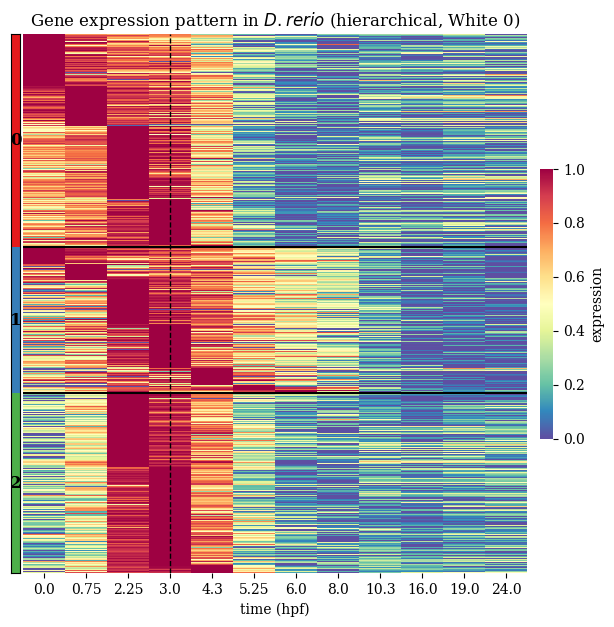

[debug] genes surviving normalisation: 4538 / 4591


C:\Users\mgrho\AppData\Local\Temp\ipykernel_14780\1444993260.py:115: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


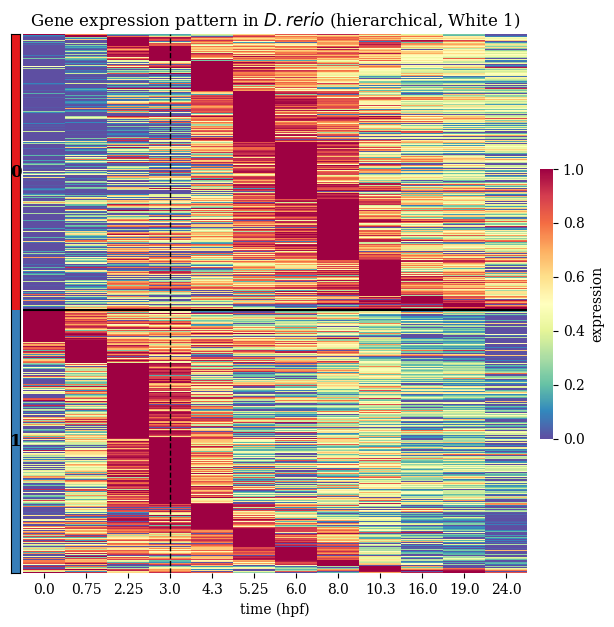

[debug] genes surviving normalisation: 4755 / 4767


C:\Users\mgrho\AppData\Local\Temp\ipykernel_14780\1444993260.py:115: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


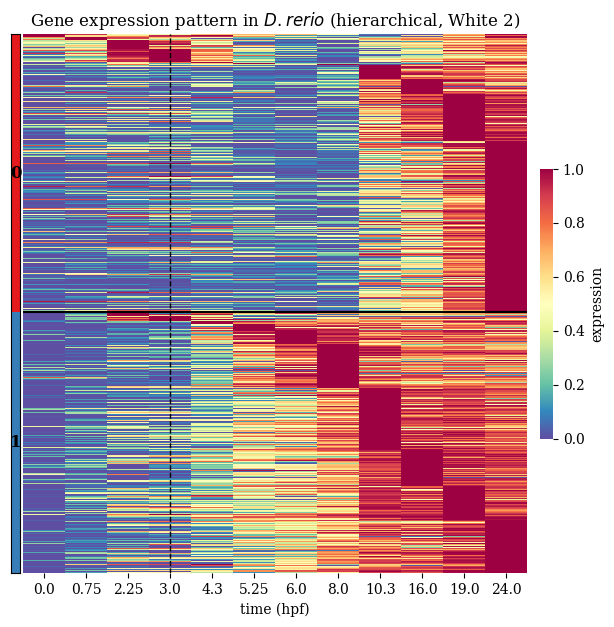

[debug] genes surviving normalisation: 4528 / 4603


C:\Users\mgrho\AppData\Local\Temp\ipykernel_14780\1444993260.py:115: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


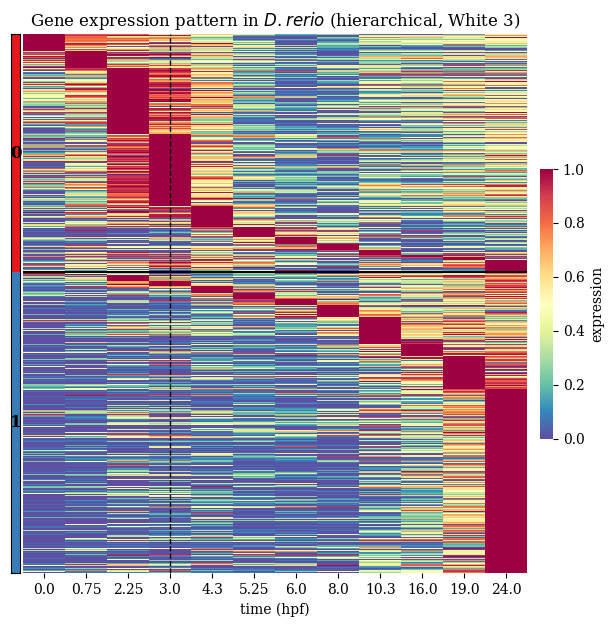

In [55]:
for i in range(4):
    plot_heatmap_supercluster("results/all_gene_cluster_annotation_minmax.nc", cluster_col="subcluster",
                data_name="White", algo="hierarchical", source="White et al.", supercluster=i)

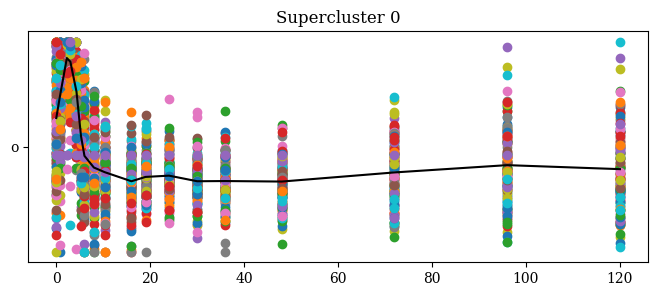

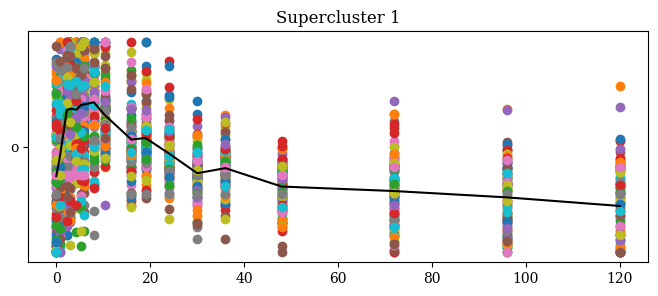

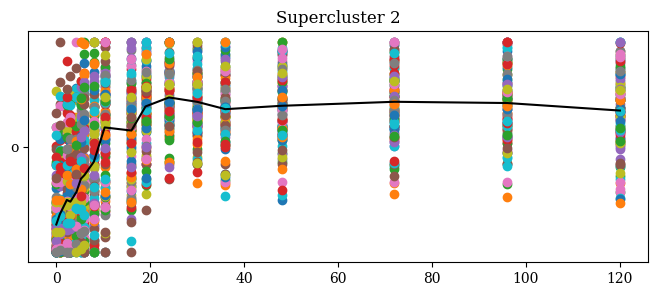

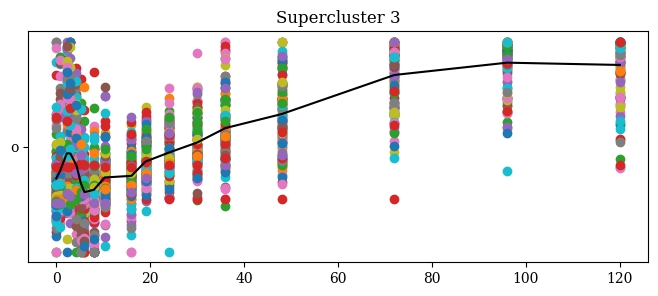

In [60]:
ann = xr.load_dataset("results/all_gene_cluster_annotation_minmax.nc").sel(source="White et al.", drop=True)
ann = ann.dropna(dim="time", how="all", subset=["tpm"])
ann = ann.sel(ensembl_gene_id=ann.ensembl_gene_id.values[0:500])

ann["tpm"] = np.log2(ann.tpm+1)

for s in np.unique(ann.supercluster.values):
    plt.figure(figsize=(8, 3))
    X = ann.sel(ensembl_gene_id=ann.supercluster == s).tpm
    X_z = (X - X.mean("time")) / abs(X- X.mean("time")).max("time")

    if "source" in X_z.dims:
        tpm = tpm.mean(dim="source", skipna=True)   # or .sel(source="...") for one source

    plt.plot(X.time, X_z, "o")
    plt.plot(X.time, X_z.mean(dim="ensembl_gene_id"), "k", "o")
    plt.title(f"Supercluster {s}")
    plt.show()

### Sankey diagramm

In [61]:
from pySankey.sankey import sankey
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def cluster_agreement(ds1, ds2, algo1, algo2):

   df1 = pd.DataFrame({"ensembl_gene_id": ds1.ensembl_gene_id.values, "cluster":ds1.cluster_label.values})
   df2 = pd.DataFrame({"ensembl_gene_id": ds2.ensembl_gene_id.values, "cluster2":ds2.cluster.values})

   dup1 = df1["ensembl_gene_id"].duplicated().sum()
   dup2 = df2["ensembl_gene_id"].duplicated().sum()
   if dup1 or dup2:
      print(f"Warning: {dup1} duplicate ids in ds1, {dup2} duplicate ids in ds2")

   df = df1.merge(df2, on="ensembl_gene_id", how="inner", validate="one_to_one")

   df["agreement"] = (df["cluster"] == df["cluster2"])
   df = df.dropna(subset=["cluster", "cluster2"])
   df = df.sort_values(["cluster", "cluster2"], ascending=False)

   sankey(left=df["cluster"], right=df["cluster2"], 
         aspect=20, fontsize=12,
         figure_name=f"figs/cluster_agreement_{algo1}_{algo2}")

   # Get current figure
   fig = plt.gcf()
   fig.set_size_inches(6, 6)
   fig.set_facecolor("w")
   plt.title(f"Cluster changes ({algo1} → {algo2})")
   fig.savefig(f"figs/cluster_agreement_{algo1}_{algo2}.png", bbox_inches="tight", dpi=300)

   agree = df["agreement"].sum() / len(df) * 100
   print(f"Cluster agreement: {agree:.2f} %")

   return df

Cluster agreement: 69.13 %


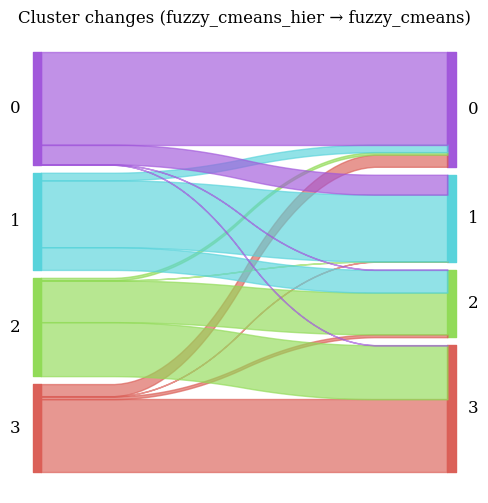

In [62]:
algo1 = "fuzzy_cmeans_hier"
ds1 = xr.load_dataset("results/all_superclusters_labels.nc")

algo2 = "fuzzy_cmeans"
ds2 = xr.load_dataset("results/fuzzy_c-means_clustered_ds_White et al..nc")

# algo2 = "ts_k-means"
# ds2 = xr.load_dataset("results/ts_k-means_euclidean_clustered_ds_White et al..nc")

#algo2 = "k-medoids"
#ds2 = xr.load_dataset("results/k_medoids_clustered_ds_White et al..nc")

df = cluster_agreement(ds1, ds2, algo1, algo2)